In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("tracks2026.csv")
df_original = df # Safety measure for manipulation of data

In [3]:
# Attempting to remove NA values from the dataset, there seems to be a pattern of if there are N/A values for a variable it is 40, 
# I am going to try to find if the N/A's are all in the same 40 rows, I believe I can just remove those rows if that is the case


# Count N/A values per row
na_per_row = df.isnull().sum(axis=1)

# Find rows with at least one N/A
rows_with_na = na_per_row[na_per_row > 0]

print("Statistics for rows with N/A values:")
print(f"Number of rows with at least 1 N/A: {len(rows_with_na)}")
print(f"Average N/A's per affected row: {rows_with_na.mean():.2f}")
print(f"\nDistribution of N/A counts in affected rows:")
print(rows_with_na.value_counts().sort_index())
print(f"\nHypothesis check - Do all N/A's cluster in same rows?")
print(f"Max N/A's in a single row: {rows_with_na.max()}")
print(f"Total unique rows with N/A: {len(rows_with_na)}")
print(f"Total N/A values in dataset: {df.isnull().sum().sum()}")

Statistics for rows with N/A values:
Number of rows with at least 1 N/A: 40
Average N/A's per affected row: 4.97

Distribution of N/A counts in affected rows:
4     1
5    39
Name: count, dtype: int64

Hypothesis check - Do all N/A's cluster in same rows?
Max N/A's in a single row: 5
Total unique rows with N/A: 40
Total N/A values in dataset: 199


All of the data rows with non applicaples seem to fall within the same 40 rows.

Seeing this issue I believe we could remove those 40 data rows and still have a strong model.

I will remove those 40 data rows now.

In [4]:
# Remove all rows with NA values
df = df.dropna()

print(f"Dataset shape after removing NA values: {df.shape}")
print(f"Original data set with no NA values removed: {df_original.shape}")
print(f"Rows removed: {len(df_original) - len(df)}")
print(f"\nVerification - Missing values remaining: {df.isnull().sum().sum()}")

Dataset shape after removing NA values: (1960, 17)
Original data set with no NA values removed: (2000, 17)
Rows removed: 40

Verification - Missing values remaining: 0


Reviewing the document for Exploritory Data Analysis recommends Log Transformation and Standard Scaler for acousticness and valence, and Log Transfer for Robust Scaler for all other columns, I will set up and apply those to the data

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Define column groups
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'popularity', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p)),
    ('scaler', StandardScaler())
])

preprocess_outliers = Pipeline([
    ('scaler', RobustScaler())  # Removed log to avoid issues with negative values like loudness
])


# Combined preprocessor (will be fitted separately for each dataset)
preprocessor = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers', preprocess_outliers, outlier_cols),
        ('passthrough', 'passthrough', passthrough_cols)
    ]
)

In [10]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nPercentage of missing values: {df.isnull().sum().sum() / len(df) * 100:.2f}%")

# Also check info
print("\nDataFrame info:")
df.info()

Missing values per column:
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Total missing values: 0

Percentage of missing values: 0.00%

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 1960 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          1960 non-null   object 
 1   popularity        1960 non-null   float64
 2   duration_ms       1960 non-null   int64  
 3   explicit          1960 non-null   bool   
 4   danceability      1960 non-null   float64
 5   energy            1960 non-null   float64
 6   key               1960 n

According to EDA valance, popularity and aucusticness don't have outliers

In [11]:
# Identify columns with outliers (excluding valence, popularity, acousticness)
outlier_columns = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ['valence', 'popularity', 'acousticness']]

# Function to detect outliers using IQR
def is_outlier(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

# Create a mask for rows with outliers in any of the outlier_columns
outlier_mask = df[outlier_columns].apply(is_outlier).any(axis=1)

# Split the dataset
df_without_outliers = df[~outlier_mask]
df_with_outliers = df[outlier_mask]

print(f"Original dataset size: {len(df)}")
print(f"Dataset without outliers: {len(df_without_outliers)}")
print(f"Dataset with outliers: {len(df_with_outliers)}")

# Check min values for no_outlier_cols
print("Min values for no_outlier_cols:")
print(df[['valence', 'popularity', 'acousticness']].min())

Original dataset size: 1960
Dataset without outliers: 1091
Dataset with outliers: 869
Min values for no_outlier_cols:
valence         0.035900
popularity      0.000000
acousticness    0.000007
dtype: float64


In [12]:
# Check min/max for all outlier columns to identify positive vs negative
print("Min and Max values for outlier columns:")
print(df[outlier_columns].describe().loc[['min', 'max']])
print("\n\nColumns with negative values:")
for col in outlier_columns:
    if df[col].min() < 0:
        print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")

print("\n\nColumns with only positive values:")
for col in outlier_columns:
    if df[col].min() >= 0:
        print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")

Min and Max values for outlier columns:
     duration_ms  danceability  energy   key  loudness  mode  speechiness  \
min      60000.0         0.185  0.0909   0.0   -21.089   0.0       0.0221   
max     561133.0         0.953  0.9960  11.0    -0.079   1.0       0.5150   

     instrumentalness  liveness    tempo  time_signature  
min             0.000   0.00986   51.037             1.0  
max             0.962   0.98600  205.895             5.0  


Columns with negative values:
loudness: min=-21.0890, max=-0.0790


Columns with only positive values:
duration_ms: min=60000.0000, max=561133.0000
danceability: min=0.1850, max=0.9530
energy: min=0.0909, max=0.9960
key: min=0.0000, max=11.0000
mode: min=0.0000, max=1.0000
speechiness: min=0.0221, max=0.5150
instrumentalness: min=0.0000, max=0.9620
liveness: min=0.0099, max=0.9860
tempo: min=51.0370, max=205.8950
time_signature: min=1.0000, max=5.0000


In [8]:
# Apply preprocessing to the datasets
# Fit and transform separately for each dataset to ensure proper scaling

df_without_outliers_transformed = pd.DataFrame(
    preprocessor.fit_transform(df_without_outliers),
    columns=df.columns
)

df_with_outliers_transformed = pd.DataFrame(
    preprocessor.fit_transform(df_with_outliers),
    columns=df.columns
)

# Now df_without_outliers_transformed and df_with_outliers_transformed are preprocessed

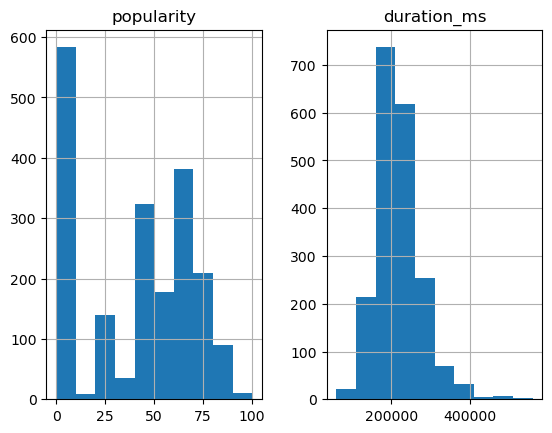

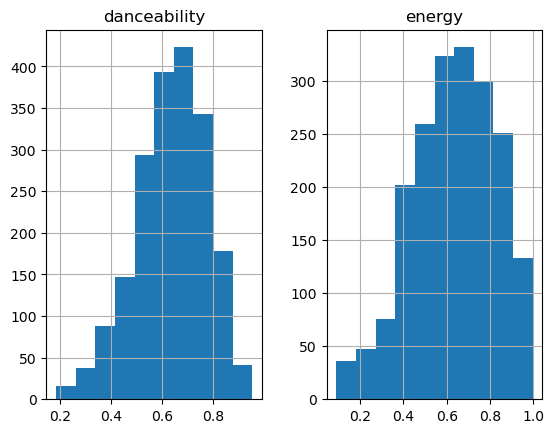

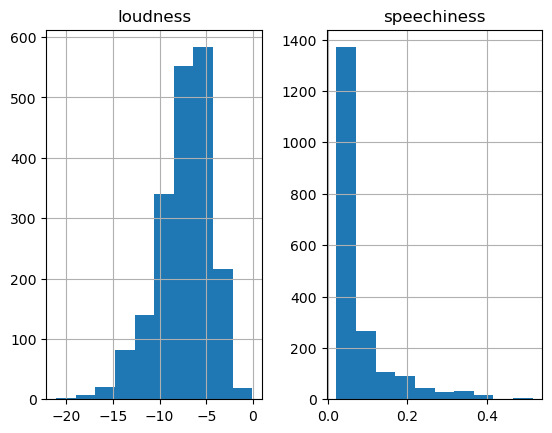

In [9]:
df[['popularity','duration_ms']].hist()
plt.show()
df[['danceability', 'energy']].hist()
plt.show()
df[['loudness', 'speechiness']].hist()
plt.show()